In [304]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from netCDF4 import Dataset

In [409]:
id = 0
range_dead = [0, 3, 6, 7]
path = "/Users/pp/data/Simulations/A08_Hydraulics_standalone/2024/swiss/LHS/k_lower_layer_reduced"
path = "/Users/pp/data/Simulations/A08_Hydraulics_standalone/2024/swiss/LHS/constraind_kylem"
path = "/Users/pp/data/Simulations/A08_Hydraulics_standalone/2024/swiss/LHS/constraind_more_kylem"
path = "/Users/pp/data/Simulations/A08_Hydraulics_standalone/2024/swiss/LHS/less_ks_more_constrained"
path = "/Users/pp/data/Simulations/A08_Hydraulics_standalone/2024/swiss/LHS/14-4"

In [410]:
df_alive= pd.read_csv(f"{path}/Best_Alive_avg.csv").head(10000)
df_dead= pd.read_csv(f'{path}/Best_dead_{id}.csv').head(10000)

In [411]:
df_alive['alive'] = 1
df_dead['alive'] = 0

In [412]:
df_dead[f"{id}"].describe()

count    10000.000000
mean         0.841028
std          0.015603
min          0.756300
25%          0.834117
50%          0.845791
75%          0.852739
max          0.857567
Name: 0, dtype: float64

In [413]:
df = pd.concat([df_alive, df_dead])
df['k_soil_top'] = np.log10(df['k_soil_sats'].str.split(';').str[0].astype(float))
df['clay_frac_1'] = df['clay_fracs'].str.split(';').str[0].astype(float)
df['clay_frac_2'] = df['clay_fracs'].str.split(';').str[1].astype(float)
df['sand_frac_1'] = df['sand_fracs'].str.split(';').str[0].astype(float)
df['sand_frac_2'] = df['sand_fracs'].str.split(';').str[1].astype(float)

In [414]:
df_alive['soil_profile_index'].describe()

count    10000.000000
mean         3.478000
std          2.283865
min          0.000000
25%          1.000000
50%          3.000000
75%          5.000000
max          7.000000
Name: soil_profile_index, dtype: float64

In [415]:
df_dead['soil_profile_index'].describe()

count    10000.000000
mean         3.510200
std          2.302222
min          0.000000
25%          1.000000
50%          3.000000
75%          6.000000
max          7.000000
Name: soil_profile_index, dtype: float64

In [416]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [417]:
cols = ['stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value',
       'psi50_xylem', 'psi88_xylem', 'leaf_hydraulic_capacitance',
       'leaf_area_index', 'psi_leaf_50_close', 'd_50_close', 'g0', 'g1','jackson_root_beta' , 'soil_profile_index','k_soil_top', 'clay_frac_1', 'clay_frac_2', 'sand_frac_1', 'sand_frac_2', 'root_area_index']

In [418]:
#cols = ['stem_hydraulic_capacitance', 'huber_value',
       'psi50_xylem', 'psi88_xylem', 'leaf_hydraulic_capacitance',
       'leaf_area_index', 'psi_leaf_50_close', 'd_50_close', 'g0', 'g1','jackson_root_beta' , 'soil_profile_index','k_soil_top', 'clay_frac_1', 'clay_frac_2', 'sand_frac_1', 'sand_frac_2', 'root_area_index']

IndentationError: unexpected indent (240129960.py, line 2)

In [419]:
from enum import Enum
class State(Enum):
    Alive = 0
    Dead = 1

In [420]:
X_train, X_test, y_train, y_test = train_test_split(df[cols], df['alive'], test_size=0.20, random_state=42)

In [421]:
est = RandomForestClassifier(n_estimators=1000, random_state=42, n_jobs=4, max_depth=10, class_weight = "balanced", bootstrap=True)
est.fit(X_train, y_train)
print(f"Train R2 score: {est.score(X_train, y_train):.2f}")
print(f"Test R2 score: {est.score(X_test, y_test):.2f}")
sorted_idx = est.feature_importances_.argsort()

Train R2 score: 0.98
Test R2 score: 0.94


Text(0.5, 0, 'Variable importance')

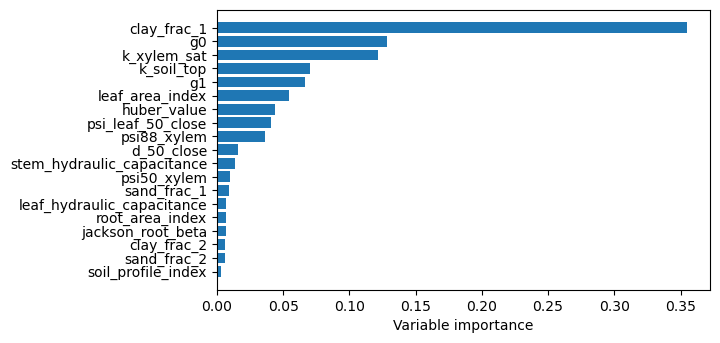

In [422]:
fig = plt.figure(figsize=(14,8))
ax = fig.add_subplot(2, 2, 1)
ax.barh(np.asarray(cols)[sorted_idx], est.feature_importances_[sorted_idx])
ax.set_xlabel('Variable importance')

In [423]:
df_dead['clay_frac_1']

KeyError: 'clay_frac_1'

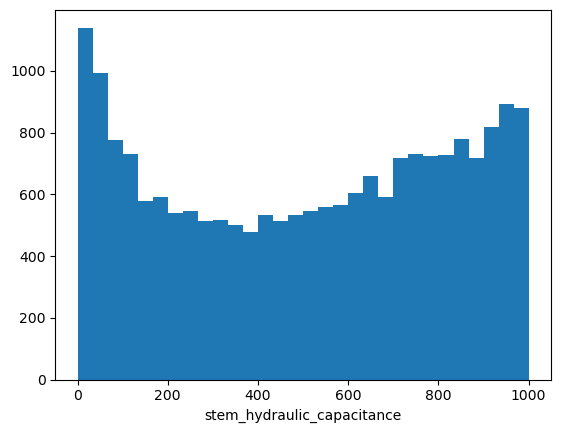

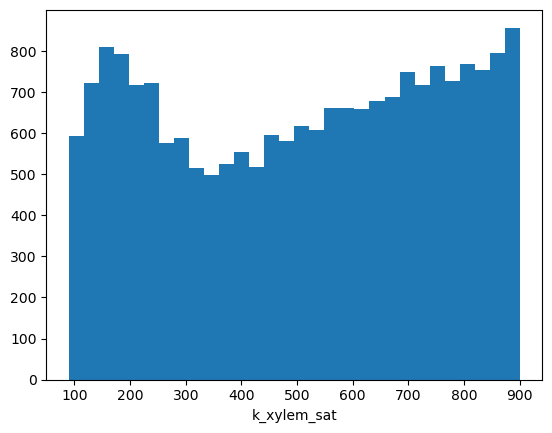

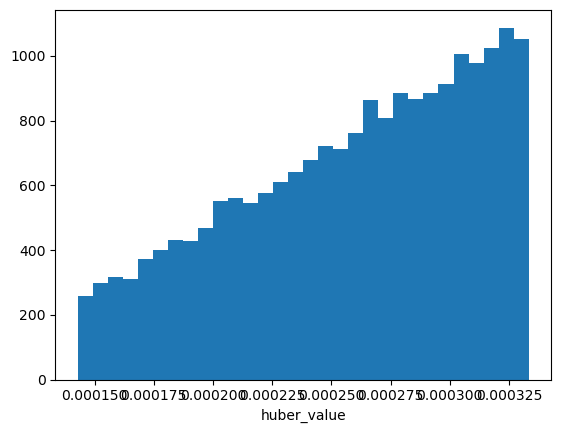

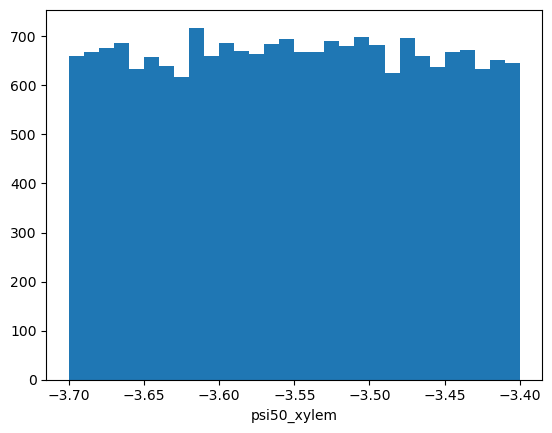

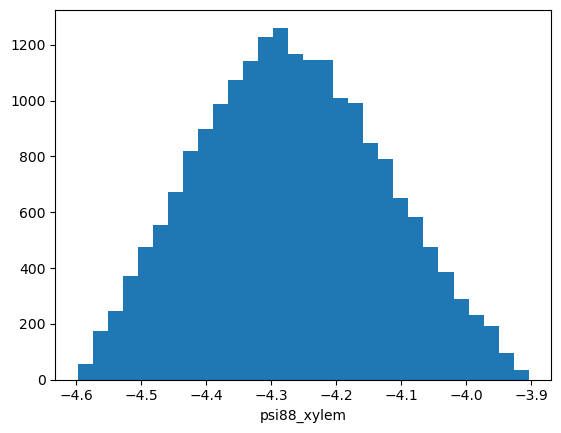

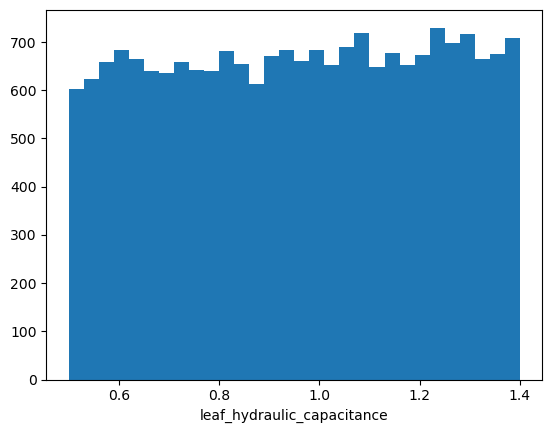

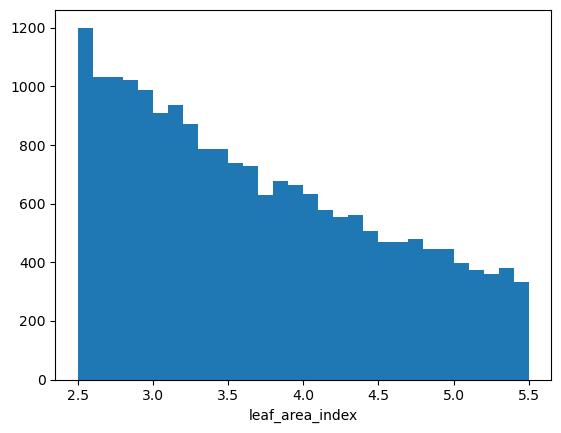

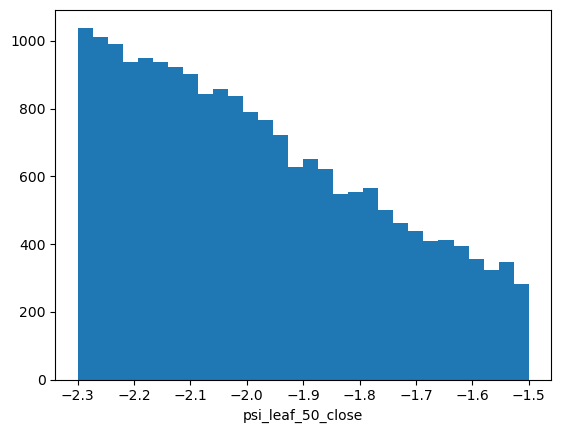

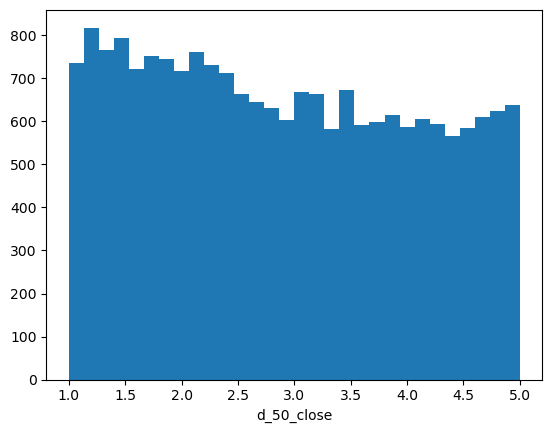

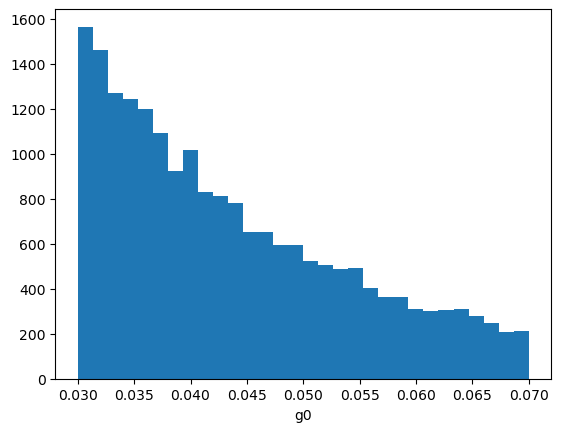

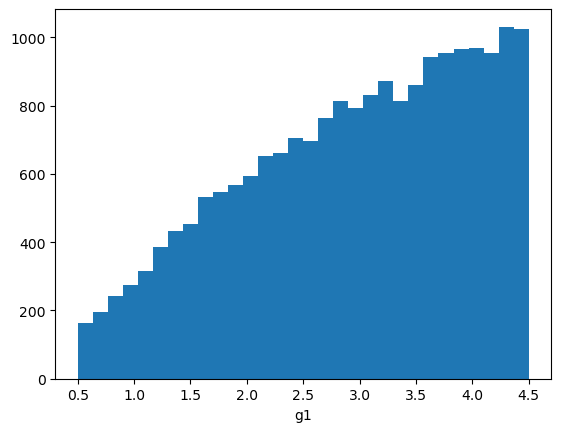

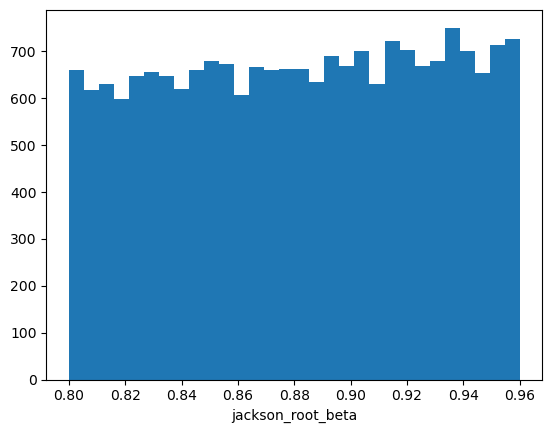

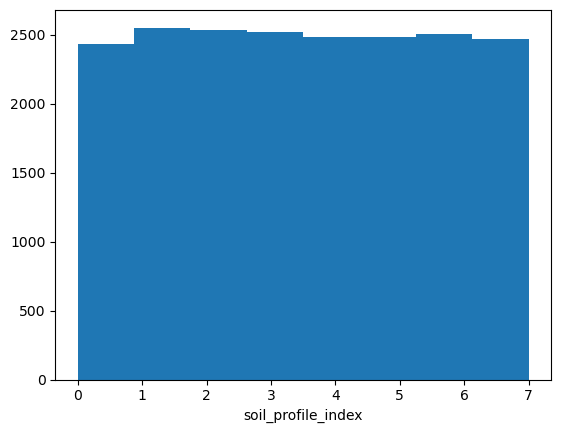

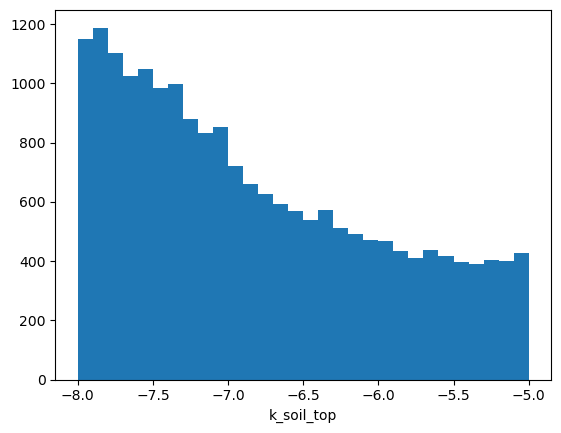

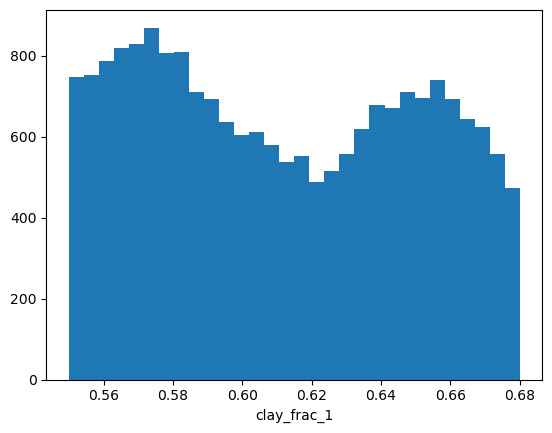

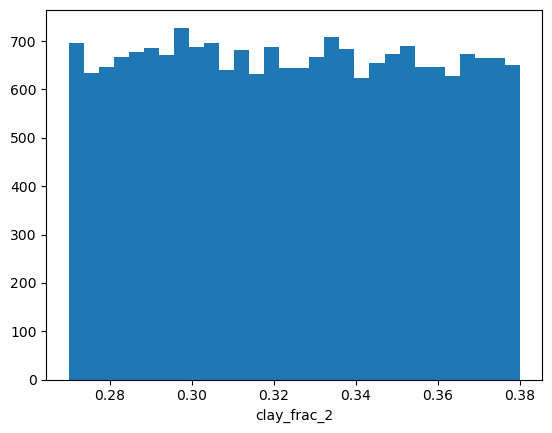

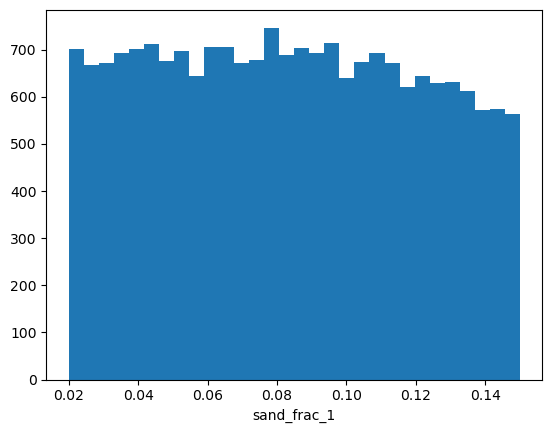

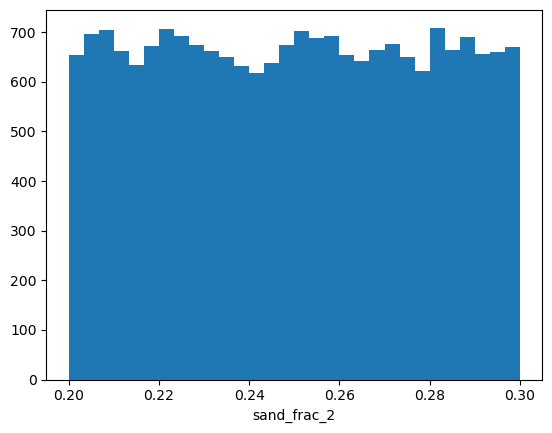

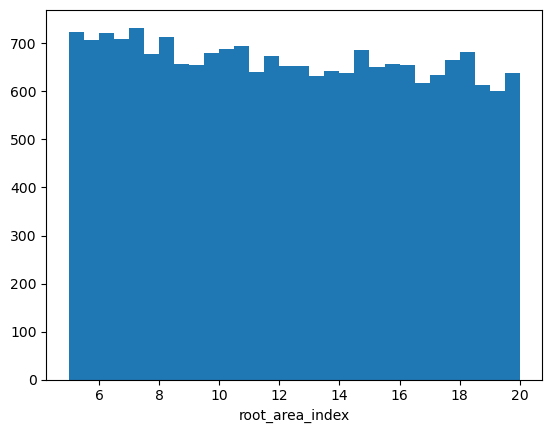

In [390]:
for col in cols:
    bins = 30
    if col == 'soil_profile_index':
        plt.hist(df[col], bins = 8)
    elif col == 'k_soil_top':
        plt.hist((df[col]), bins = bins)
    else:
        plt.hist(df[col], bins = bins)
    plt.xlabel(col)
    plt.show()

In [72]:
df[0].describe()

KeyError: 0

In [432]:
plt.scatter(df[df['alive']==0]['k_soil_top']
            , df[df['alive']==0]['soil_profile_index'], alpha = 0.)1)

SyntaxError: unmatched ')' (3619332742.py, line 2)

In [62]:
df[df[2] < 1.0]

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
